In [36]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline
import gdown
import pandas as pd
from scipy.stats import pearsonr
import random

In [6]:
#pip install gdown

In [61]:
G=nx.read_edgelist('Wiki-Vote.txt',create_using=nx.DiGraph())
print('Nodes:',G.number_of_nodes()) # и выводим основные свойства
print('Edges:',G.number_of_edges())
print('Density:',nx.density(G))
print('Reciprocity:', nx.reciprocity(G))

print(G)

Nodes: 7115
Edges: 103689
Density: 0.0020485375110809584
Reciprocity: 0.0564572905515532
DiGraph with 7115 nodes and 103689 edges


Распределение степеней

In [8]:
from collections import Counter
# Вычисление степеней
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
total_degrees = [d for n, d in G.degree()]

In [87]:

def get_degree_distribution(degrees, log_bins=True):
    degree_counts = Counter(degrees)
    deg_values = np.array(list(degree_counts.keys()))
    deg_counts = np.array(list(degree_counts.values()))

    sort_idx = np.argsort(deg_values)
    deg_values = deg_values[sort_idx]
    deg_counts = deg_counts[sort_idx]
    
    return deg_values, deg_counts

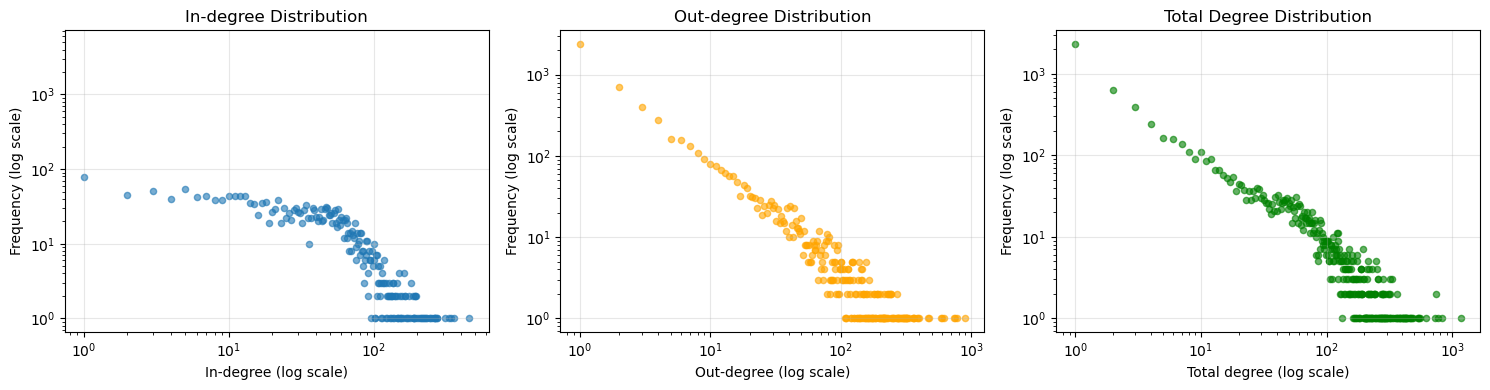

In [88]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# In-degree distribution
in_vals, in_counts = get_degree_distribution(in_degrees)
axes[0].scatter(in_vals, in_counts, alpha=0.6, s=20)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('In-degree (log scale)')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('In-degree Distribution')
axes[0].grid(True, alpha=0.3)

# Out-degree distribution
out_vals, out_counts = get_degree_distribution(out_degrees)
axes[1].scatter(out_vals, out_counts, alpha=0.6, s=20, color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Out-degree (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Out-degree Distribution')
axes[1].grid(True, alpha=0.3)

# Total degree distribution
total_vals, total_counts = get_degree_distribution(total_degrees)
axes[2].scatter(total_vals, total_counts, alpha=0.6, s=20, color='green')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Total degree (log scale)')
axes[2].set_ylabel('Frequency (log scale)')
axes[2].set_title('Total Degree Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Статистические свойства
print(f"Средний in-degree: {np.mean(in_degrees):.2f}")
print(f"Средний out-degree: {np.mean(out_degrees):.2f}")
print(f"Максимальный in-degree: {max(in_degrees)}")
print(f"Максимальный out-degree: {max(out_degrees)}")
print(f"Медиана in-degree: {np.median(in_degrees)}")
print(f"Медиана out-degree: {np.median(out_degrees)}")

Средний in-degree: 14.57
Средний out-degree: 14.57
Максимальный in-degree: 457
Максимальный out-degree: 893
Медиана in-degree: 0.0
Медиана out-degree: 2.0


Вывод:
Средние значения:

Средний in-degree: 14.57
Средний out-degree: 14.57
Максимальный in-degree: 457
Максимальный out-degree: 893
Медианы (типичные значения):
Медиана in-degree: 0.0 
Медиана out-degree: 2.0 -> отдано 2 

Распределение степеней подчиняется степенному закону

Ассортативность

In [27]:
# Для направленного графа нужно вычислить ассортативность по разным комбинациям степеней
# Создаем списки степеней для каждой вершины
in_in = []
in_out = []
out_in = []
out_out = []

for u, v in G.edges():
    in_in.append((G.in_degree(u), G.in_degree(v)))
    in_out.append((G.in_degree(u), G.out_degree(v)))
    out_in.append((G.out_degree(u), G.in_degree(v)))
    out_out.append((G.out_degree(u), G.out_degree(v)))


In [28]:
# Вычисляем коэффициенты корреляции

def compute_correlation(degree_pairs):
    if len(degree_pairs) == 0:
        return 0
    x, y = zip(*degree_pairs)
    return pearsonr(x, y)[0]

In [29]:
print("Ассортативность (коэффициенты корреляции Пирсона):")
print(f"in-in:   {compute_correlation(in_in):.4f}")
print(f"in-out:  {compute_correlation(in_out):.4f}")
print(f"out-in:  {compute_correlation(out_in):.4f}")
print(f"out-out: {compute_correlation(out_out):.4f}")


Ассортативность (коэффициенты корреляции Пирсона):
in-in:   0.0051
in-out:  0.0071
out-in:  -0.0832
out-out: -0.0189


Итог: Сеть ДИЗАССОРТАТИВНАЯ (в основном), слабые эффекты преобладают, 

Связность

In [86]:
# Сильно связные компоненты (SCC)
scc = list(nx.strongly_connected_components(G))
scc_sizes = [len(comp) for comp in scc]
largest_scc = max(scc, key=len)

# Слабо связные компоненты (WCC)
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = [len(comp) for comp in wcc]
largest_wcc = max(wcc, key=len)

print(f"Количество сильно связных компонент: {len(scc)}")
print(f"Количество слабо связных компонент: {len(wcc)}")
print(f"\nРазмер наибольшей сильно связной компоненты (LSCC): {len(largest_scc)} вершин")
print(f"Размер наибольшей слабо связной компоненты (LWCC): {len(largest_wcc)} вершин")
print(f"Доля вершин в LSCC: {len(largest_scc)/G.number_of_nodes():.2%}")

Количество сильно связных компонент: 5816
Количество слабо связных компонент: 24

Размер наибольшей сильно связной компоненты (LSCC): 1300 вершин
Размер наибольшей слабо связной компоненты (LWCC): 7066 вершин
Доля вершин в LSCC: 18.27%


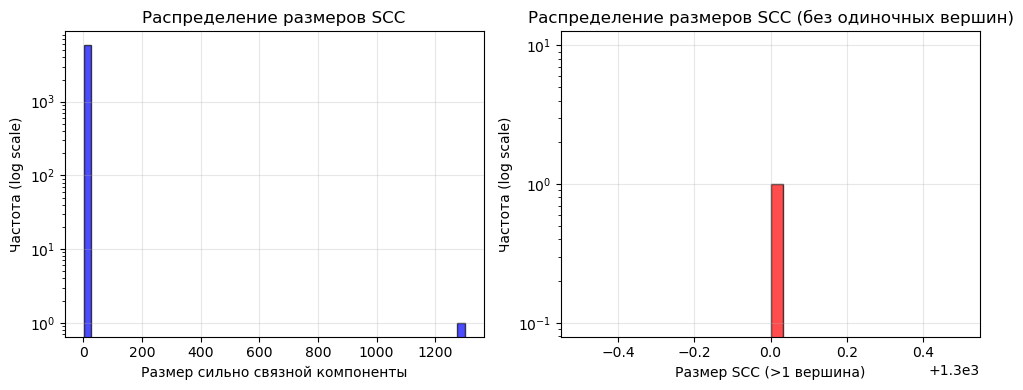

In [31]:
# Распределение размеров сильно связных компонент
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(scc_sizes, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Размер сильно связной компоненты')
plt.ylabel('Частота (log scale)')
plt.title('Распределение размеров SCC')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Без учета компонент размера 1 для лучшей визуализации
scc_sizes_greater_than_1 = [s for s in scc_sizes if s > 1]
plt.hist(scc_sizes_greater_than_1, bins=30, alpha=0.7, color='red', edgecolor='black')
plt.yscale('log')
plt.xlabel('Размер SCC (>1 вершина)')
plt.ylabel('Частота (log scale)')
plt.title('Распределение размеров SCC (без одиночных вершин)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:
print(f"Количество SCC размера 1: {scc_sizes.count(1)}")
print(f"Количество SCC размера > 10: {len([s for s in scc_sizes if s > 10])}")
print(f"Максимальный размер SCC: {max(scc_sizes)}")
print(f"Минимальный размер SCC: {min(scc_sizes)}")

Количество SCC размера 1: 5815
Количество SCC размера > 10: 1
Максимальный размер SCC: 1300
Минимальный размер SCC: 1


не является сильно связной - только 18% вершин взаимно достижимы
является слабо связной - 99.3% вершин образуют один большой компонент

1300 вершин в сильно связной компоненте
Это 18.27% от всех вершин сети

In [85]:

G_lscc = G.subgraph(largest_scc).copy()

print(f"Размер подграфа LSCC: {G_lscc.number_of_nodes()} вершин, {G_lscc.number_of_edges()} ребер")

Размер подграфа LSCC: 1300 вершин, 39456 ребер


Кратчайшие пути

In [82]:
# Вычисляем среднюю длину кратчайшего пути
# Для больших графов используем аппроксимацию
try:
    if G_lscc.number_of_nodes() < 5000:
        avg_path_length = nx.average_shortest_path_length(G_lscc)
        print(f"Средняя длина кратчайшего пути (точный расчет): {avg_path_length:.4f}")
    else:
        
        # Выборка пар вершин
        import random
        nodes = list(G_lscc.nodes())
        num_samples = min(1000, len(nodes) * 10)
        
        path_lengths = []
        for _ in range(num_samples):
            u, v = random.sample(nodes, 2)
            try:
                length = nx.shortest_path_length(G_lscc, u, v)
                path_lengths.append(length)
            except nx.NetworkXNoPath:
                continue
        
        if path_lengths:
            avg_sampled = np.mean(path_lengths)
            print(f"Средняя длина кратчайшего пути (по {len(path_lengths)} выборкам): {avg_sampled:.4f}")
            
        reachable_pairs = 0
        total_path_length = 0
        
        sample_nodes = random.sample(nodes, min(100, len(nodes)))
        
        for source in sample_nodes:
            lengths = nx.single_source_shortest_path_length(G_lscc, source)
            reachable_pairs += len(lengths) - 1  # исключаем саму вершину
            total_path_length += sum(lengths.values()) - lengths[source]  # исключаем путь к себе
        
        if reachable_pairs > 0:
            estimated_avg = total_path_length / reachable_pairs
            print(f"Оценка средней длины пути: {estimated_avg:.4f}")
            
        try:
            all_lengths = []
            for source in random.sample(nodes, min(50, len(nodes))):
                lengths = nx.single_source_shortest_path_length(G_lscc, source)
                all_lengths.extend(list(lengths.values()))
            
            eff_diameter = np.percentile(all_lengths, 90)
            print(f"Эффективный диаметр (90-й процентиль): {eff_diameter:.2f}")
            
        except:
            pass
        
except Exception as e:    

    density_lscc = nx.density(G_lscc)
    print(f"Плотность: {density_lscc:.6f}")

    try:
        nodes = list(G_lscc.nodes())
        diameters = []
        
        for _ in range(100):
            u, v = random.sample(nodes, 2)
            try:
                d = nx.shortest_path_length(G_lscc, u, v)
                diameters.append(d)
            except:
                continue
        
        if diameters:
            print(f"Максимальная длина пути: {max(diameters)}")
            print(f"Средняя длина пути: {np.mean(diameters):.2f}")
    except:
        pass


Средняя длина кратчайшего пути (точный расчет): 2.8793


In [40]:
print(f"Транзитивность: {nx.transitivity(G):.4f}")
print(f"Средний кластерный коэффициент: {nx.average_clustering(G):.4f}")

Транзитивность: 0.0529
Средний кластерный коэффициент: 0.0816


Пункт 2 (задание 2)

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import seaborn as sns

df=pd.read_csv('spreading_data_wiki-Vote.csv')
df.head()


,node,spreading ability
0,30,0.277864
1,1412,0.000141
2,3352,0.280253
3,5254,0.278426
4,5543,0.274209


In [47]:
spreading_values = df['spreading ability'].values.reshape(-1, 1)

scaler = StandardScaler()
spreading_scaled = scaler.fit_transform(spreading_values)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
classes = kmeans.fit_predict(spreading_scaled)


In [48]:
mean_values = [np.mean(spreading_values[classes == i]) for i in range(2)]
good_class_kmeans = 0 if mean_values[0] > mean_values[1] else 1
good_class_median = 1  

df['class_kmeans'] = classes
df['good_spreader_kmeans'] = (df['class_kmeans'] == good_class_kmeans).astype(int)

/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_15094/2210777708.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/0w/pg719rr9519435t25t6yf2hm0000gn/T/ipykernel_15094/2210777708.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(box_data, labels=['Плохие', 'Хорошие'])


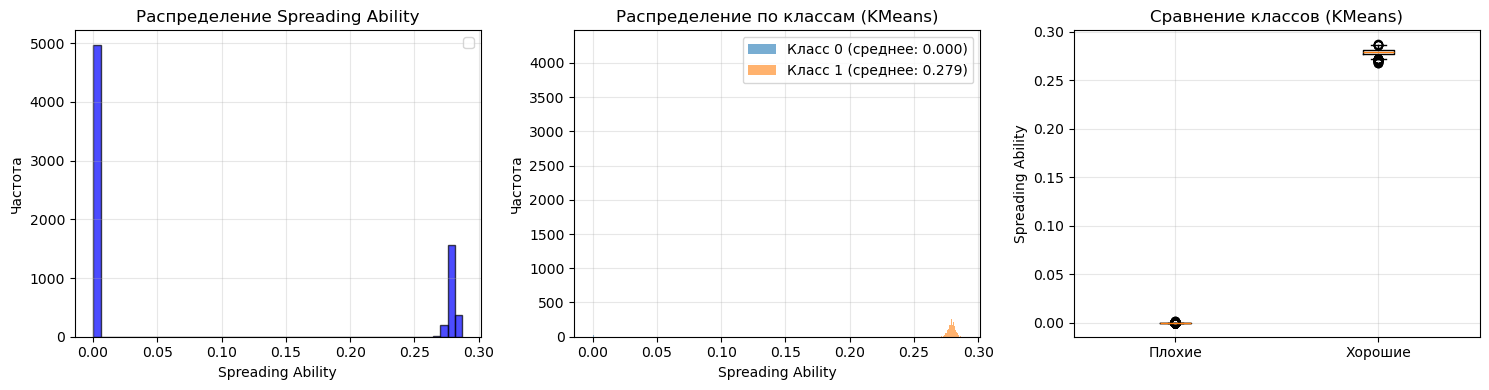

In [51]:
# Визуализация распределения spreading ability
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограмма spreading ability
axes[0].hist(df['spreading ability'], bins=50, alpha=0.7, color='blue', edgecolor='black')
# axes[0].axvline(x=median_value, color='red', linestyle='--', label=f'Медиана: {median_value:.3f}')
axes[0].set_xlabel('Spreading Ability')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение Spreading Ability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Распределение по классам (KMeans)
for i in range(2):
    subset = df[df['class_kmeans'] == i]
    axes[1].hist(subset['spreading ability'], bins=30, alpha=0.6, 
                 label=f'Класс {i} (среднее: {subset["spreading ability"].mean():.3f})')
axes[1].set_xlabel('Spreading Ability')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение по классам (KMeans)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Box plot сравнение
box_data = [df[df['good_spreader_kmeans'] == 0]['spreading ability'],
            df[df['good_spreader_kmeans'] == 1]['spreading ability']]
axes[2].boxplot(box_data, labels=['Плохие', 'Хорошие'])
axes[2].set_ylabel('Spreading Ability')
axes[2].set_title('Сравнение классов (KMeans)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

In [63]:
df['good_spreader'] = df['good_spreader_kmeans']
y_true = df['good_spreader'].values


In [67]:
df['node'] = df['node'].astype(str) 

# 1. PageRank
pagerank = nx.pagerank(G)
df['pagerank'] = df['node'].map(pagerank)

# 2. In-Degree Centrality - сколько голосов получает участник
in_degree = dict(G.in_degree())
df['in_degree'] = df['node'].map(in_degree)

# 3. Betweenness
# Вычисляем для подвыборки, т.к. долгий расчет

out_degree_dict = dict(G.out_degree())
df['out_degree'] = df['node'].map(out_degree_dict)

In [69]:
print(f"PageRank: min={df['pagerank'].min():.6f}, max={df['pagerank'].max():.6f}, mean={df['pagerank'].mean():.6f}")
print(f"In-Degree: min={df['in_degree'].min()}, max={df['in_degree'].max()}, mean={df['in_degree'].mean():.2f}")
print(f"Out-Degree: min={df['out_degree'].min()}, max={df['out_degree'].max()}, mean={df['out_degree'].mean():.2f}")


PageRank: min=0.000050, max=0.004613, mean=0.000141
In-Degree: min=0, max=457, mean=14.57
Out-Degree: min=0, max=893, mean=14.57


In [70]:
# Метрики для сравнения
metrics = ['pagerank', 'in_degree', 'out_degree']
names = ['PageRank', 'In-Degree', 'Out-Degree']

# Считаем AUC
results = []
for metric, name in zip(metrics, names):
    y_score = df[metric].values
    
    y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min())
    
    # AUC-ROC
    auc = roc_auc_score(y_true, y_score_norm)
    fpr, tpr, _ = roc_curve(y_true, y_score_norm)
    
    results.append({
        'name': name,
        'auc': auc,
        'fpr': fpr,
        'tpr': tpr
    })
    
    print(f"{name}: AUC = {auc:.3f}")

PageRank: AUC = 0.579
In-Degree: AUC = 0.583
Out-Degree: AUC = 0.912


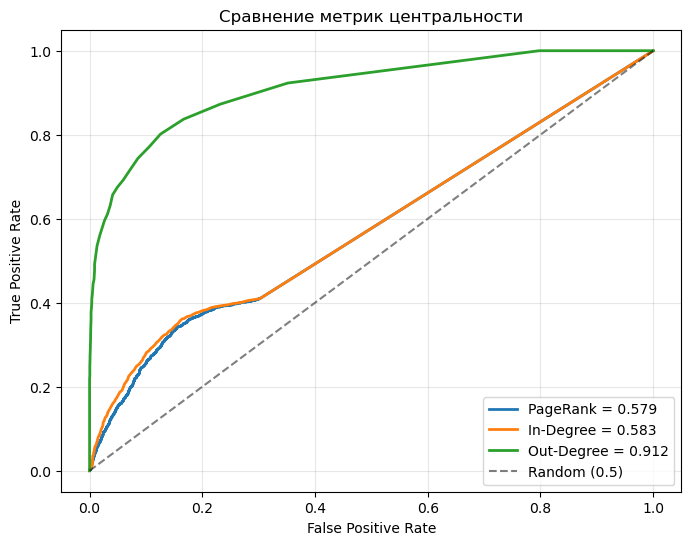

In [73]:
plt.figure(figsize=(8, 6))

for res in results:
    plt.plot(res['fpr'], res['tpr'], 
             label=f"{res['name']} = {res['auc']:.3f}",
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение метрик центральности')
plt.legend()
plt.grid(True, alpha=0.3)plt.show()

In [78]:
out_norm = (df['out_degree'] - df['out_degree'].min()) / (df['out_degree'].max() - df['out_degree'].min())
in_norm = (df['in_degree'] - df['in_degree'].min()) / (df['in_degree'].max() - df['in_degree'].min())

sigmas = np.linspace(0, 1, 21)
auc_values = []

for sigma in sigmas:
    # σ * In-Degree + (1-σ) * Out-Degree
    hybrid = sigma * in_norm + (1 - sigma) * out_norm
    
    # Считаем AUC
    auc = roc_auc_score(y_true, hybrid)
    auc_values.append(auc)
    
    if sigma in [0, 0.25, 0.5, 0.75, 1.0]:
        print(f"σ = {sigma:.2f}: AUC = {auc:.3f}")

best_idx = np.argmax(auc_values)
best_sigma = sigmas[best_idx]
best_auc = auc_values[best_idx]

print(f"\nОптимальный sigma = {best_sigma:.3f} (AUC = {best_auc:.3f})")

σ = 0.00: AUC = 0.912
σ = 0.25: AUC = 0.830
σ = 0.50: AUC = 0.788
σ = 0.75: AUC = 0.757
σ = 1.00: AUC = 0.583

Оптимальный sigma = 0.000 (AUC = 0.912)


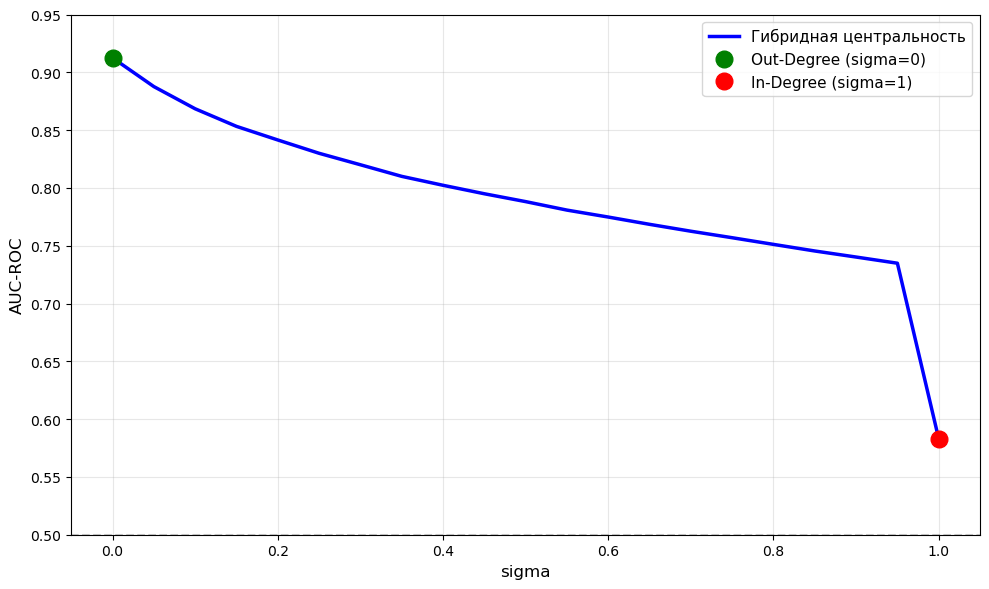

In [81]:
sigmas_all = np.linspace(0, 1, 21)
aucs_all = []

for s in sigmas_all:
    hybrid = s * in_norm + (1-s) * out_norm
    aucs_all.append(roc_auc_score(y_true, hybrid))

plt.figure(figsize=(10, 6))
plt.plot(sigmas_all, aucs_all, 'b-', linewidth=2.5, label='Гибридная центральность')

# Особые точки
plt.plot(0, 0.912, 'go', markersize=12, label='Out-Degree (sigma=0)')
plt.plot(1, 0.583, 'ro', markersize=12, label='In-Degree (sigma=1)')

plt.xlabel('sigma', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.title('', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.2)
plt.ylim(0.5, 0.95)
plt.tight_layout()
plt.show()

Пункт 3 (Задание 3)

In [89]:
def generate_directed_ER(n, p, r):
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    
    for i in range(n):
        for j in range(n):
            if i != j and np.random.random() < p:
                rand = np.random.random()
                if rand < r:
                    G.add_edge(i, j)
                    G.add_edge(j, i)
                else:
                    G.add_edge(i, j)
    
    return G

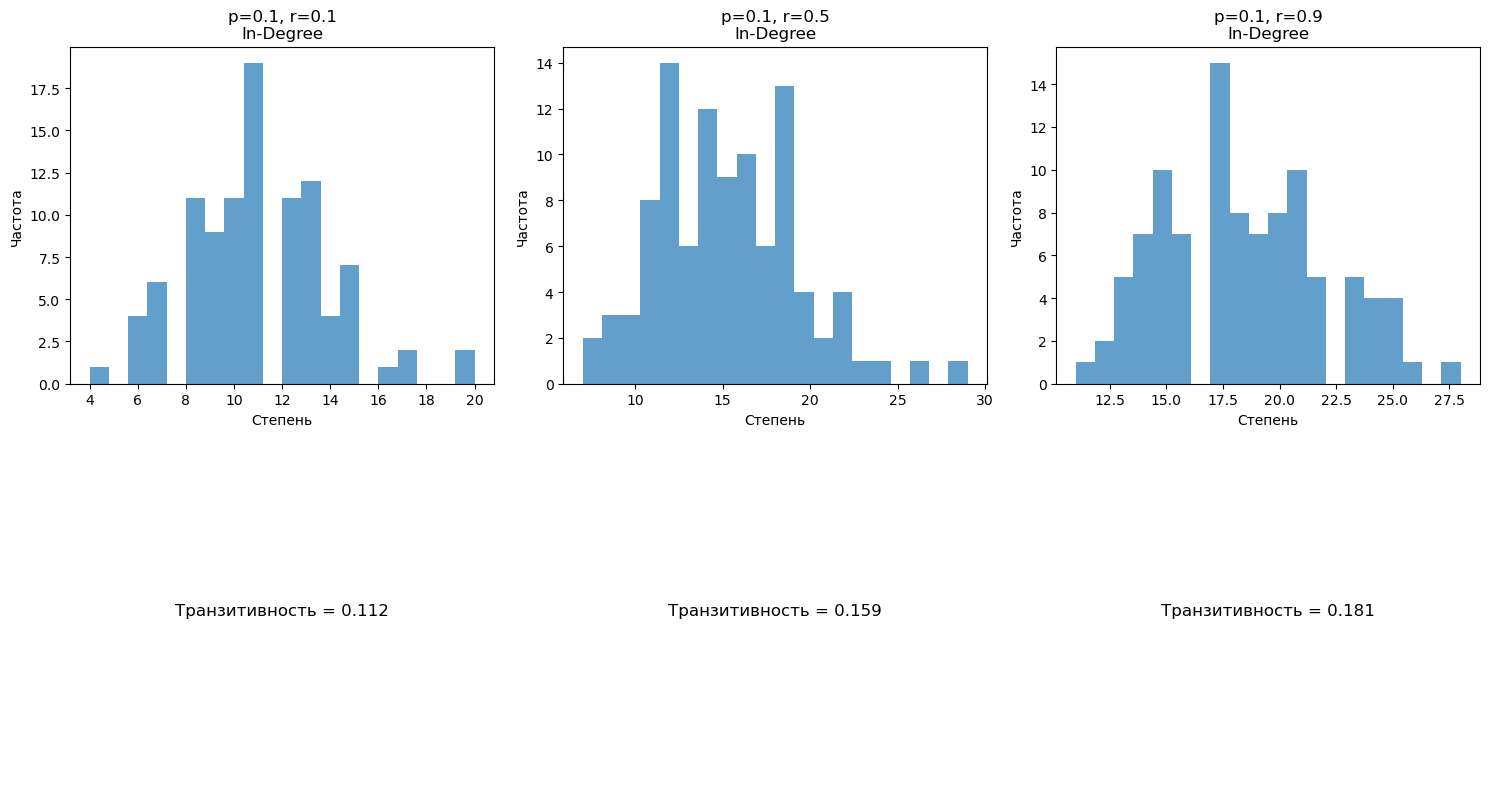

In [96]:
n = 100  # вершин
pairs = [(0.1, 0.1), (0.1, 0.5), (0.1, 0.9)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (p, r) in enumerate(pairs):
    
    G = generate_directed_ER(n, p, r)
    
    # Распределение степеней
    in_degrees = [d for _, d in G.in_degree()]
    axes[0, idx].hist(in_degrees, bins=20, alpha=0.7)
    axes[0, idx].set_title(f'p={p}, r={r}\nIn-Degree')
    axes[0, idx].set_xlabel('Степень')
    axes[0, idx].set_ylabel('Частота')
    
    # Транзитивность
    transitivity = nx.transitivity(G)
    axes[1, idx].text(0.5, 0.5, f'Транзитивность = {transitivity:.3f}', 
                     ha='center', va='center', fontsize=12)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

r = 0.0: Транзитивность = 0.100, Средний путь = 2.25
r = 0.1: Транзитивность = 0.106, Средний путь = 2.17
r = 0.2: Транзитивность = 0.116, Средний путь = 2.14
r = 0.3: Транзитивность = 0.118, Средний путь = 2.03
r = 0.4: Транзитивность = 0.135, Средний путь = 1.99
r = 0.5: Транзитивность = 0.148, Средний путь = 1.97
r = 0.6: Транзитивность = 0.153, Средний путь = 1.93
r = 0.7: Транзитивность = 0.177, Средний путь = 1.88
r = 0.8: Транзитивность = 0.176, Средний путь = 1.86
r = 0.9: Транзитивность = 0.183, Средний путь = 1.85
r = 1.0: Транзитивность = 0.184, Средний путь = 1.84


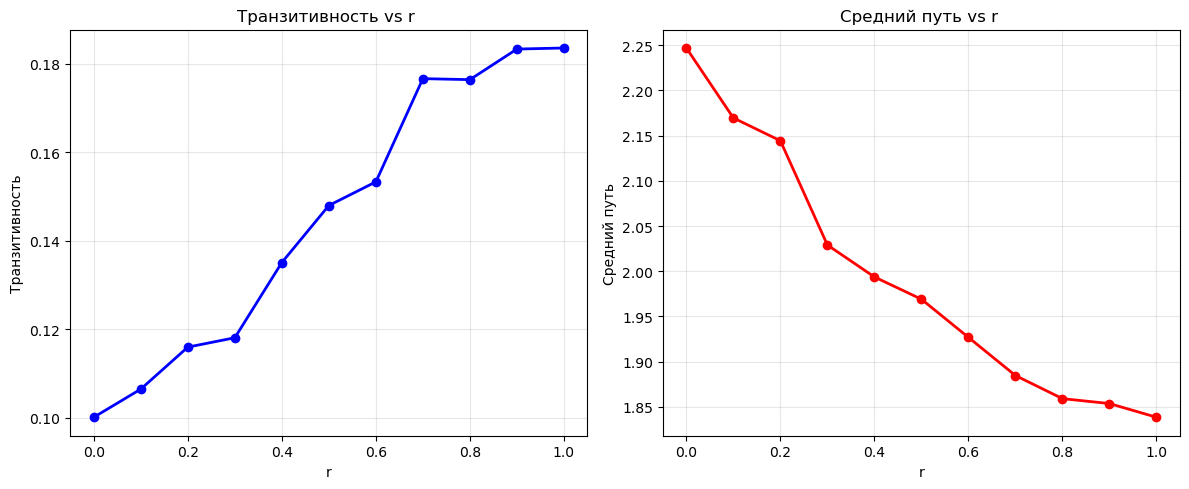

In [98]:
# Фиксируем p, меняем r
p_fixed = 0.1
r_values = np.linspace(0, 1, 11)  # [0, 0.1, 0.2, ..., 1.0]
transitivity_values = []
avg_path_values = []

for r in r_values:
    G = generate_directed_ER(100, p_fixed, r)
    
    # Транзитивность
    trans = nx.transitivity(G)
    transitivity_values.append(trans)
    
    try:
        avg_path = nx.average_shortest_path_length(G)
    except:
        avg_path = np.nan
    avg_path_values.append(avg_path)
    
    print(f"r = {r:.1f}: Транзитивность = {trans:.3f}, Средний путь = {avg_path:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Транзитивность
axes[0].plot(r_values, transitivity_values, 'bo-', linewidth=2)
axes[0].set_xlabel('r')
axes[0].set_ylabel('Транзитивность')
axes[0].set_title('Транзитивность vs r ')
axes[0].grid(True, alpha=0.3)

# Средний путь
axes[1].plot(r_values, avg_path_values, 'ro-', linewidth=2)
axes[1].set_xlabel('r')
axes[1].set_ylabel('Средний путь')
axes[1].set_title('Средний путь vs r ')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Двунаправленные связи = более надежные маршруты \
Можно ходить в обе стороны по одному ребру \
Граф становится "плотнее" и лучше связан